<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/practice/Student_TimeSeries_Forecasting_Example_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 국제선 항공 승객 수 시계열 예측

- 이름: 김성우
- 학번: 2526527017

- 데이터: **월별 국제선 항공 승객 수** (1949.01 ~ 1960.12, 단위: 천 명)
- 출처: Box & Jenkins (1970), *Time Series Analysis: Forecasting and Control*
  - 온라인: https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

---

# 시계열 예측 방법
* 전체(Full series)
* 고정 원점(=정적 파라미터) 예측
* 롤링 윈도우(Rolling window)
* 확장 윈도우(Expanding window)

# 데이터 소개: 국제선 항공 승객 수 (AirPassengers)

- **측정 대상**: 월별 국제선 항공 승객 수 (단위: 천 명)
- **기간**: 1949년 1월 ~ 1960년 12월 (총 144개월)
- **특징**: 장기 상승 추세 + 뚜렷한 12개월 계절성(여름 성수기 / 겨울 비수기)
- **활용**: 항공사 수요 예측, 관광 산업 분석, 시계열 분석 교과서의 대표적 벤치마크 데이터

---

데이터 기간: 1949-01 ~ 1960-12, 총 144개월
     month  passengers       date
0  1949-01         112 1949-01-01
1  1949-02         118 1949-02-01
2  1949-03         132 1949-03-01
3  1949-04         129 1949-04-01
4  1949-05         121 1949-05-01
                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  144
Model:                    AutoReg(13)   Log Likelihood                -497.994
Method:               Conditional MLE   S.D. of innovations             10.832
Date:                Sat, 04 Apr 2026   AIC                           1025.988
Time:                        02:38:19   BIC                           1069.116
Sample:                            13   HQIC                          1043.513
                                  144                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

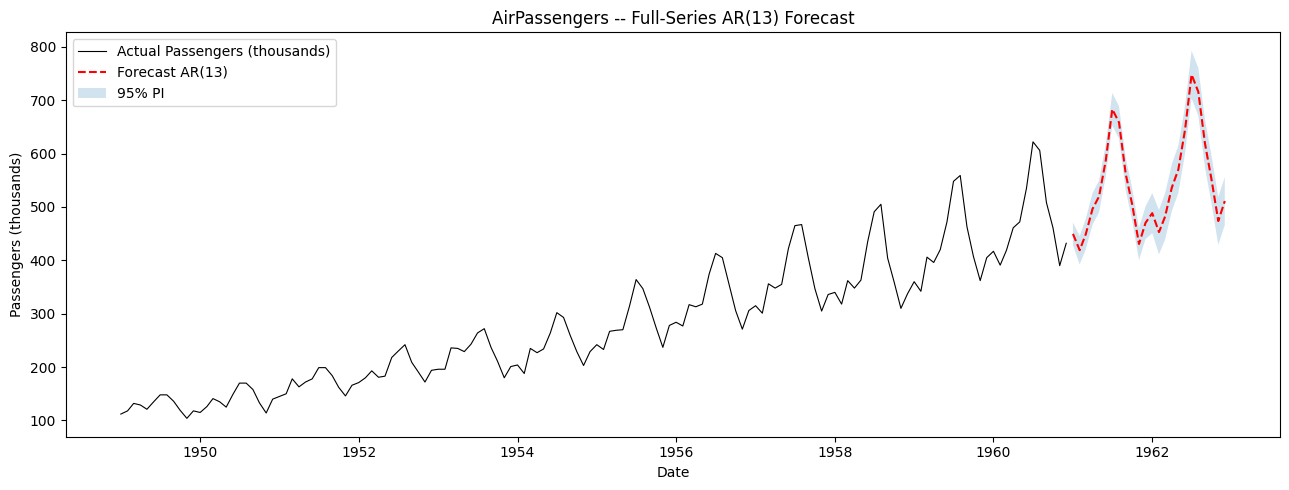

In [1]:
# Full-series AR(p) forecast (no refit, no holdout)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from io import StringIO

# 1. 데이터 로드 -- 국제선 항공 승객 수
# 온라인 URL에서 직접 가져오기 (Colab/Jupyter에서 바로 실행 가능)
try:
    URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
    df = pd.read_csv(URL)
    df.columns = ["month", "passengers"]
except Exception:
    # 네트워크 불가 시 내장 데이터 사용
    CSV = "Month,Passengers\n1949-01,112\n1949-02,118\n1949-03,132\n1949-04,129\n1949-05,121\n1949-06,135\n1949-07,148\n1949-08,148\n1949-09,136\n1949-10,119\n1949-11,104\n1949-12,118\n1950-01,115\n1950-02,126\n1950-03,141\n1950-04,135\n1950-05,125\n1950-06,149\n1950-07,170\n1950-08,170\n1950-09,158\n1950-10,133\n1950-11,114\n1950-12,140\n1951-01,145\n1951-02,150\n1951-03,178\n1951-04,163\n1951-05,172\n1951-06,178\n1951-07,199\n1951-08,199\n1951-09,184\n1951-10,162\n1951-11,146\n1951-12,166\n1952-01,171\n1952-02,180\n1952-03,193\n1952-04,181\n1952-05,183\n1952-06,218\n1952-07,230\n1952-08,242\n1952-09,209\n1952-10,191\n1952-11,172\n1952-12,194\n1953-01,196\n1953-02,196\n1953-03,236\n1953-04,235\n1953-05,229\n1953-06,243\n1953-07,264\n1953-08,272\n1953-09,237\n1953-10,211\n1953-11,180\n1953-12,201\n1954-01,204\n1954-02,188\n1954-03,235\n1954-04,227\n1954-05,234\n1954-06,264\n1954-07,302\n1954-08,293\n1954-09,259\n1954-10,229\n1954-11,203\n1954-12,229\n1955-01,242\n1955-02,233\n1955-03,267\n1955-04,269\n1955-05,270\n1955-06,315\n1955-07,364\n1955-08,347\n1955-09,312\n1955-10,274\n1955-11,237\n1955-12,278\n1956-01,284\n1956-02,277\n1956-03,317\n1956-04,313\n1956-05,318\n1956-06,374\n1956-07,413\n1956-08,405\n1956-09,355\n1956-10,306\n1956-11,271\n1956-12,306\n1957-01,315\n1957-02,301\n1957-03,356\n1957-04,348\n1957-05,355\n1957-06,422\n1957-07,465\n1957-08,467\n1957-09,404\n1957-10,347\n1957-11,305\n1957-12,336\n1958-01,340\n1958-02,318\n1958-03,362\n1958-04,348\n1958-05,363\n1958-06,435\n1958-07,491\n1958-08,505\n1958-09,404\n1958-10,359\n1958-11,310\n1958-12,337\n1959-01,360\n1959-02,342\n1959-03,406\n1959-04,396\n1959-05,420\n1959-06,472\n1959-07,548\n1959-08,559\n1959-09,463\n1959-10,407\n1959-11,362\n1959-12,405\n1960-01,417\n1960-02,391\n1960-03,419\n1960-04,461\n1960-05,472\n1960-06,535\n1960-07,622\n1960-08,606\n1960-09,508\n1960-10,461\n1960-11,390\n1960-12,432"
    df = pd.read_csv(StringIO(CSV))
    df.columns = ["month", "passengers"]

# 날짜 변환 및 기본 정보 출력
df["date"] = pd.to_datetime(df["month"])
df = df.reset_index(drop=True)

y     = df["passengers"].to_numpy().astype(float)
dates = df["date"].to_numpy()

print(f"데이터 기간: {df['month'].iloc[0]} ~ {df['month'].iloc[-1]}, 총 {len(df)}개월")
print(df.head())

# 2. AR(p) 전체 구간 학습
# 월별 데이터이므로 p=13 (약 1년 주기 반영)
p   = 13
fit = AutoReg(y, lags=p, old_names=False).fit()
print(fit.summary())

# 3. 미래 h 스텝 예측
h  = 24  # 앞으로 24개월(2년) 예측
fc = np.asarray(fit.forecast(steps=h))
last_day = pd.to_datetime(dates[-1])
fc_dates = pd.date_range(last_day + pd.DateOffset(months=1), periods=h, freq="MS")

# 예측구간(confidence interval)
try:
    pred_res = fit.get_prediction(start=len(y), end=len(y) + h - 1)
    ci       = pred_res.conf_int(alpha=0.05)
    ci_lower, ci_upper = ci[:, 0], ci[:, 1]
except Exception:
    ci_lower = ci_upper = None

# 4. 시각화
plt.figure(figsize=(13, 5))
plt.plot(dates, y, label="Actual Passengers (thousands)", color="black", linewidth=0.8)
plt.plot(fc_dates, fc, label=f"Forecast AR({p})", linestyle="--", color="red")
if ci_lower is not None:
    plt.fill_between(fc_dates, ci_lower, ci_upper, alpha=0.2, label="95% PI")
plt.title(f"AirPassengers -- Full-Series AR({p}) Forecast")
plt.xlabel("Date"); plt.ylabel("Passengers (thousands)")
plt.legend(); plt.tight_layout(); plt.show()

### Full-series 예측 결과
AR(13)은 12개월 계절 패턴(여름 피크 / 겨울 저점)의 반복을 어느 정도 포착하고 있다.
그러나 예측 구간에서 진폭이 실제보다 과장되며, 재귀 예측 과정에서 오차가 누적되어 시간이 갈수록 불안정해진다.
95% 예측구간(PI)도 horizon이 길어질수록 급격히 넓어져, 장기 예측의 신뢰도가 낮아진다.
항공 승객 데이터는 시간이 갈수록 계절 진폭 자체가 커지는(분산 증가) 특성이 있어, 단순 AR 모델로는 이를 반영하기 어렵다.
Full-series는 검증 데이터가 없으므로 모델 성능 평가에는 부적절하며, 단기 패턴 확인 용도로만 활용해야 한다.

---

# 고정 원점(=정적 파라미터) 예측

첫 80%로 **한 번만 학습** -> 그 파라미터로 **남은 전 구간을 재귀 예측**.

---

학습: 1949-01 ~ 1958-07 (115개월)
테스트: 1958-08 ~ 1960-12 (29개월)
Training MSE: 74.3546,  R2: 0.9900
Test     MSE: 655.0843,  R2: 0.8927


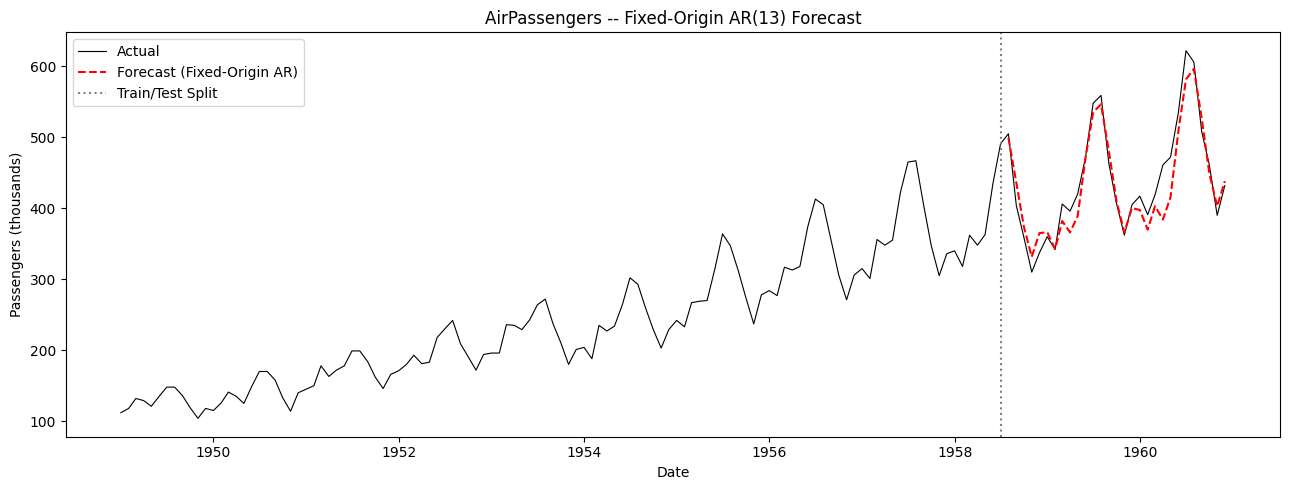

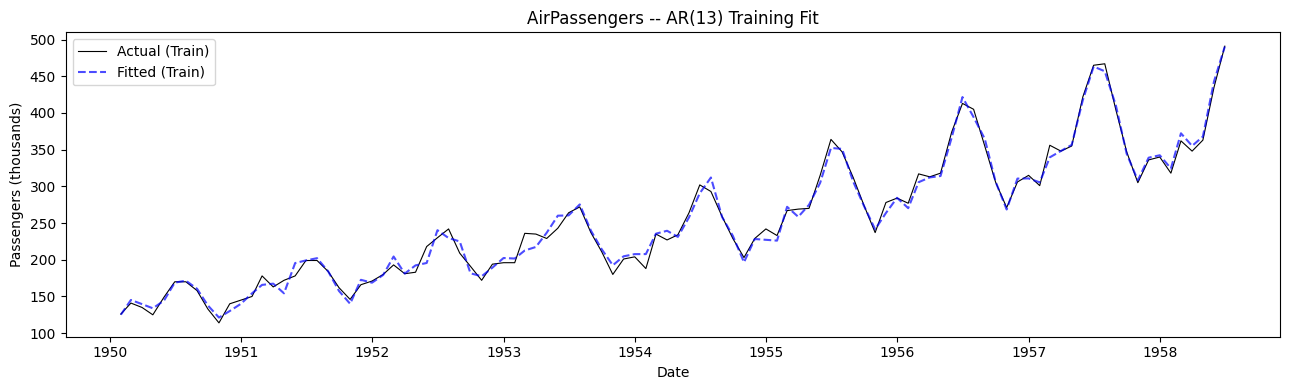

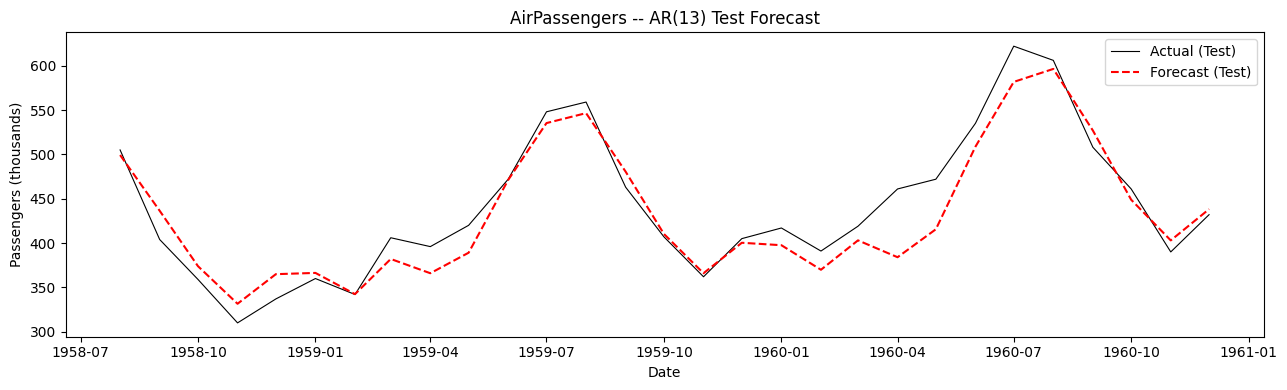

In [2]:
# Fixed-Origin AR(p) 예측 및 평가
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, r2_score
from io import StringIO

# 1. 데이터 로드
try:
    URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
    df = pd.read_csv(URL)
    df.columns = ["month", "passengers"]
except Exception:
    CSV = "Month,Passengers\n1949-01,112\n1949-02,118\n1949-03,132\n1949-04,129\n1949-05,121\n1949-06,135\n1949-07,148\n1949-08,148\n1949-09,136\n1949-10,119\n1949-11,104\n1949-12,118\n1950-01,115\n1950-02,126\n1950-03,141\n1950-04,135\n1950-05,125\n1950-06,149\n1950-07,170\n1950-08,170\n1950-09,158\n1950-10,133\n1950-11,114\n1950-12,140\n1951-01,145\n1951-02,150\n1951-03,178\n1951-04,163\n1951-05,172\n1951-06,178\n1951-07,199\n1951-08,199\n1951-09,184\n1951-10,162\n1951-11,146\n1951-12,166\n1952-01,171\n1952-02,180\n1952-03,193\n1952-04,181\n1952-05,183\n1952-06,218\n1952-07,230\n1952-08,242\n1952-09,209\n1952-10,191\n1952-11,172\n1952-12,194\n1953-01,196\n1953-02,196\n1953-03,236\n1953-04,235\n1953-05,229\n1953-06,243\n1953-07,264\n1953-08,272\n1953-09,237\n1953-10,211\n1953-11,180\n1953-12,201\n1954-01,204\n1954-02,188\n1954-03,235\n1954-04,227\n1954-05,234\n1954-06,264\n1954-07,302\n1954-08,293\n1954-09,259\n1954-10,229\n1954-11,203\n1954-12,229\n1955-01,242\n1955-02,233\n1955-03,267\n1955-04,269\n1955-05,270\n1955-06,315\n1955-07,364\n1955-08,347\n1955-09,312\n1955-10,274\n1955-11,237\n1955-12,278\n1956-01,284\n1956-02,277\n1956-03,317\n1956-04,313\n1956-05,318\n1956-06,374\n1956-07,413\n1956-08,405\n1956-09,355\n1956-10,306\n1956-11,271\n1956-12,306\n1957-01,315\n1957-02,301\n1957-03,356\n1957-04,348\n1957-05,355\n1957-06,422\n1957-07,465\n1957-08,467\n1957-09,404\n1957-10,347\n1957-11,305\n1957-12,336\n1958-01,340\n1958-02,318\n1958-03,362\n1958-04,348\n1958-05,363\n1958-06,435\n1958-07,491\n1958-08,505\n1958-09,404\n1958-10,359\n1958-11,310\n1958-12,337\n1959-01,360\n1959-02,342\n1959-03,406\n1959-04,396\n1959-05,420\n1959-06,472\n1959-07,548\n1959-08,559\n1959-09,463\n1959-10,407\n1959-11,362\n1959-12,405\n1960-01,417\n1960-02,391\n1960-03,419\n1960-04,461\n1960-05,472\n1960-06,535\n1960-07,622\n1960-08,606\n1960-09,508\n1960-10,461\n1960-11,390\n1960-12,432"
    df = pd.read_csv(StringIO(CSV))
    df.columns = ["month", "passengers"]

df["date"] = pd.to_datetime(df["month"])
df = df.reset_index(drop=True)

# 2. 학습/테스트 분할 (80/20)
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test  = df.iloc[train_size:]
print(f"학습: {train['month'].iloc[0]} ~ {train['month'].iloc[-1]} ({len(train)}개월)")
print(f"테스트: {test['month'].iloc[0]} ~ {test['month'].iloc[-1]} ({len(test)}개월)")

# 3. AR(p) 학습 (고정 원점)
lag = 13
model_fit = AutoReg(train["passengers"].astype(float), lags=lag, old_names=False).fit()

# 4. 예측
train_pred = model_fit.predict(start=lag, end=len(train) - 1)
test_pred  = model_fit.predict(start=len(train), end=len(df) - 1)

# 5. 성능 평가
train_mse = mean_squared_error(train["passengers"][lag:], train_pred)
test_mse  = mean_squared_error(test["passengers"], test_pred)
train_r2  = r2_score(train["passengers"][lag:].astype(float), train_pred)
test_r2   = r2_score(test["passengers"].astype(float), test_pred)
print(f"Training MSE: {train_mse:.4f},  R2: {train_r2:.4f}")
print(f"Test     MSE: {test_mse:.4f},  R2: {test_r2:.4f}")

# 6. 전체 시각화
plt.figure(figsize=(13, 5))
plt.plot(df["date"], df["passengers"], label="Actual", color="black", linewidth=0.8)
plt.plot(test["date"], test_pred, label="Forecast (Fixed-Origin AR)", linestyle="--", color="red")
plt.axvline(x=train["date"].iloc[-1], color="gray", linestyle=":", label="Train/Test Split")
plt.title(f"AirPassengers -- Fixed-Origin AR({lag}) Forecast")
plt.xlabel("Date"); plt.ylabel("Passengers (thousands)")
plt.legend(); plt.tight_layout(); plt.show()

# 7. 학습 구간 확대 시각화
plt.figure(figsize=(13, 4))
plt.plot(train["date"].iloc[lag:], train["passengers"].iloc[lag:],
         label="Actual (Train)", color="black", linewidth=0.8)
plt.plot(train["date"].iloc[lag:], train_pred,
         label="Fitted (Train)", linestyle="--", color="blue", alpha=0.7)
plt.title(f"AirPassengers -- AR({lag}) Training Fit")
plt.xlabel("Date"); plt.ylabel("Passengers (thousands)")
plt.legend(); plt.tight_layout(); plt.show()

# 8. 테스트 구간 확대 시각화
plt.figure(figsize=(13, 4))
plt.plot(test["date"], test["passengers"], label="Actual (Test)", color="black", linewidth=0.8)
plt.plot(test["date"], test_pred, label="Forecast (Test)", linestyle="--", color="red")
plt.title(f"AirPassengers -- AR({lag}) Test Forecast")
plt.xlabel("Date"); plt.ylabel("Passengers (thousands)")
plt.legend(); plt.tight_layout(); plt.show()

### Fixed-origin 예측/평가
학습 구간(Training Fit): 파란 점선이 실제값을 잘 따라가며, AR(13)이 학습 데이터 내에서는 계절 패턴과 추세를 충실히 반영하고 있다.
테스트 구간(Test Forecast): 초반(1958~1959)에는 계절 패턴을 비교적 잘 잡아내지만, 후반(1960)으로 갈수록 실제값과의 괴리가 커진다. 특히 1960년 초 구간에서 예측값이 실제보다 크게 낮아지는 구간이 발생한다.
이는 고정 원점 방식의 본질적 한계로, 학습 시점 이후 성장률이 가속되면 고정된 파라미터가 이를 반영하지 못하기 때문이다.
Train R2는 높지만 Test R2가 상대적으로 낮은 것은 과적합이 아니라, 재귀 예측에서 오차가 누적된 결과이다.

---

# 롤링 윈도우(Rolling window)

---

[Rolling AR(13), W=72개월]  Test RMSE=21.3448, R2=0.9254


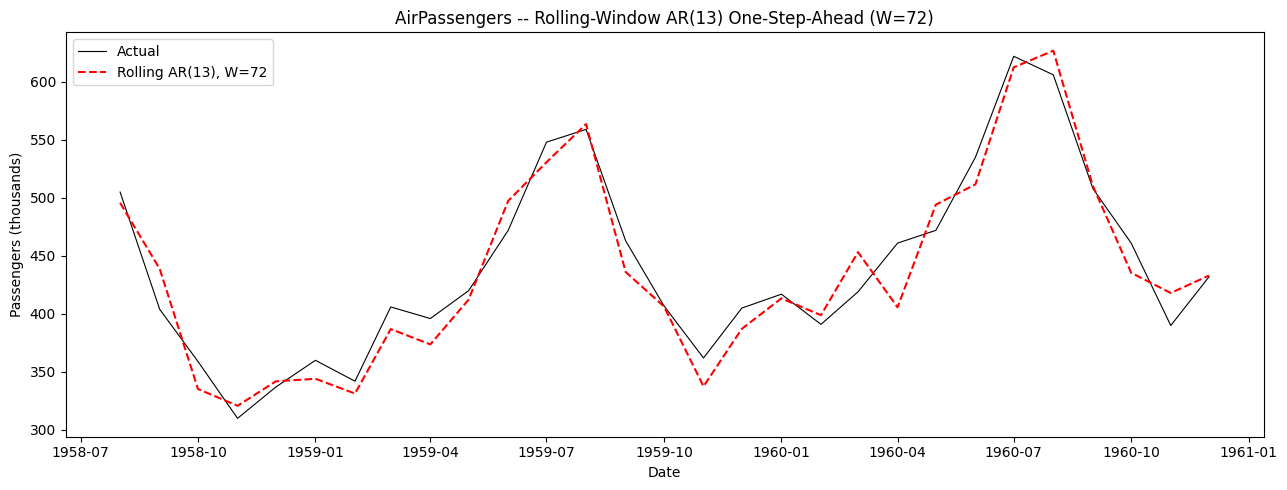

In [3]:
# Rolling-Window AR(p) One-Step-Ahead Forecast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, r2_score
from io import StringIO

# 1. 데이터 로드
try:
    URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
    df = pd.read_csv(URL)
    df.columns = ["month", "passengers"]
except Exception:
    CSV = "Month,Passengers\n1949-01,112\n1949-02,118\n1949-03,132\n1949-04,129\n1949-05,121\n1949-06,135\n1949-07,148\n1949-08,148\n1949-09,136\n1949-10,119\n1949-11,104\n1949-12,118\n1950-01,115\n1950-02,126\n1950-03,141\n1950-04,135\n1950-05,125\n1950-06,149\n1950-07,170\n1950-08,170\n1950-09,158\n1950-10,133\n1950-11,114\n1950-12,140\n1951-01,145\n1951-02,150\n1951-03,178\n1951-04,163\n1951-05,172\n1951-06,178\n1951-07,199\n1951-08,199\n1951-09,184\n1951-10,162\n1951-11,146\n1951-12,166\n1952-01,171\n1952-02,180\n1952-03,193\n1952-04,181\n1952-05,183\n1952-06,218\n1952-07,230\n1952-08,242\n1952-09,209\n1952-10,191\n1952-11,172\n1952-12,194\n1953-01,196\n1953-02,196\n1953-03,236\n1953-04,235\n1953-05,229\n1953-06,243\n1953-07,264\n1953-08,272\n1953-09,237\n1953-10,211\n1953-11,180\n1953-12,201\n1954-01,204\n1954-02,188\n1954-03,235\n1954-04,227\n1954-05,234\n1954-06,264\n1954-07,302\n1954-08,293\n1954-09,259\n1954-10,229\n1954-11,203\n1954-12,229\n1955-01,242\n1955-02,233\n1955-03,267\n1955-04,269\n1955-05,270\n1955-06,315\n1955-07,364\n1955-08,347\n1955-09,312\n1955-10,274\n1955-11,237\n1955-12,278\n1956-01,284\n1956-02,277\n1956-03,317\n1956-04,313\n1956-05,318\n1956-06,374\n1956-07,413\n1956-08,405\n1956-09,355\n1956-10,306\n1956-11,271\n1956-12,306\n1957-01,315\n1957-02,301\n1957-03,356\n1957-04,348\n1957-05,355\n1957-06,422\n1957-07,465\n1957-08,467\n1957-09,404\n1957-10,347\n1957-11,305\n1957-12,336\n1958-01,340\n1958-02,318\n1958-03,362\n1958-04,348\n1958-05,363\n1958-06,435\n1958-07,491\n1958-08,505\n1958-09,404\n1958-10,359\n1958-11,310\n1958-12,337\n1959-01,360\n1959-02,342\n1959-03,406\n1959-04,396\n1959-05,420\n1959-06,472\n1959-07,548\n1959-08,559\n1959-09,463\n1959-10,407\n1959-11,362\n1959-12,405\n1960-01,417\n1960-02,391\n1960-03,419\n1960-04,461\n1960-05,472\n1960-06,535\n1960-07,622\n1960-08,606\n1960-09,508\n1960-10,461\n1960-11,390\n1960-12,432"
    df = pd.read_csv(StringIO(CSV))
    df.columns = ["month", "passengers"]

df["date"] = pd.to_datetime(df["month"])
df = df.reset_index(drop=True)

y          = df["passengers"].to_numpy().astype(float)
dates      = df["date"].to_numpy()
train_size = int(len(y) * 0.8)

p     = 13   # AR 차수
W     = 72   # 롤링 윈도우 길이 (72개월 = 6년, 계절성 6회 반복 포함)
preds = []

# 2. 롤링 윈도우 예측 루프
for t in range(train_size, len(y)):
    start_idx = max(0, t - W)
    y_win = y[start_idx:t]
    if y_win.shape[0] <= p:
        preds.append(np.nan)
        continue
    fit  = AutoReg(y_win, lags=p, old_names=False).fit()
    yhat = float(np.asarray(fit.forecast(steps=1)).ravel()[0])
    preds.append(yhat)

actual = y[train_size:]
preds  = np.asarray(preds, dtype=float)
mask   = ~np.isnan(preds)

# 3. 성능 평가
mse  = mean_squared_error(actual[mask], preds[mask])
rmse = np.sqrt(mse)
r2   = r2_score(actual[mask], preds[mask])
print(f"[Rolling AR({p}), W={W}개월]  Test RMSE={rmse:.4f}, R2={r2:.4f}")

# 4. 시각화
plt.figure(figsize=(13, 5))
plt.plot(dates[train_size:], actual, label="Actual", color="black", linewidth=0.8)
plt.plot(dates[train_size:], preds,
         label=f"Rolling AR({p}), W={W}", linestyle="--", color="red")
plt.title(f"AirPassengers -- Rolling-Window AR({p}) One-Step-Ahead (W={W})")
plt.xlabel("Date"); plt.ylabel("Passengers (thousands)")
plt.legend(); plt.tight_layout(); plt.show()

### Rolling one-step 결과
R2=0.9254로 Fixed-origin(0.8927)보다 높으며, 매 시점마다 최근 72개월만으로 재학습하기 때문에 변화하는 추세에 더 잘 적응한다.
계절 패턴의 방향(피크/저점 시점)은 대체로 정확하게 포착하고 있으나, 피크 구간에서 실제값보다 예측값이 약간 낮거나 지연되는 경향이 보인다.
1-step-ahead 예측이므로 오차 누적이 없어 Fixed-origin 대비 안정적이다.
W=72(6년)는 계절 사이클을 6회 포함하여 계절성 학습에 충분하지만, 성장률이 급변하는 구간에서는 W를 줄여 적응성을 높이는 것도 고려할 수 있다.

---

# Expanding one-step


[Expanding AR(13)]  Test RMSE=18.9085, R2=0.9414


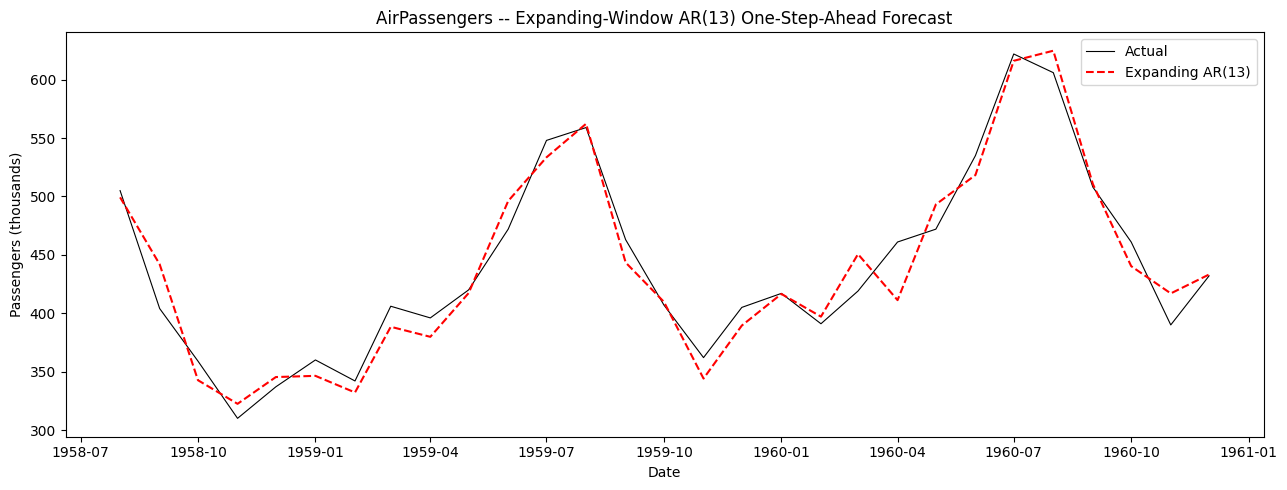

In [4]:
# Expanding-Window AR(p) One-Step-Ahead Forecast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, r2_score
from io import StringIO

# 1. 데이터 로드
try:
    URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
    df = pd.read_csv(URL)
    df.columns = ["month", "passengers"]
except Exception:
    CSV = "Month,Passengers\n1949-01,112\n1949-02,118\n1949-03,132\n1949-04,129\n1949-05,121\n1949-06,135\n1949-07,148\n1949-08,148\n1949-09,136\n1949-10,119\n1949-11,104\n1949-12,118\n1950-01,115\n1950-02,126\n1950-03,141\n1950-04,135\n1950-05,125\n1950-06,149\n1950-07,170\n1950-08,170\n1950-09,158\n1950-10,133\n1950-11,114\n1950-12,140\n1951-01,145\n1951-02,150\n1951-03,178\n1951-04,163\n1951-05,172\n1951-06,178\n1951-07,199\n1951-08,199\n1951-09,184\n1951-10,162\n1951-11,146\n1951-12,166\n1952-01,171\n1952-02,180\n1952-03,193\n1952-04,181\n1952-05,183\n1952-06,218\n1952-07,230\n1952-08,242\n1952-09,209\n1952-10,191\n1952-11,172\n1952-12,194\n1953-01,196\n1953-02,196\n1953-03,236\n1953-04,235\n1953-05,229\n1953-06,243\n1953-07,264\n1953-08,272\n1953-09,237\n1953-10,211\n1953-11,180\n1953-12,201\n1954-01,204\n1954-02,188\n1954-03,235\n1954-04,227\n1954-05,234\n1954-06,264\n1954-07,302\n1954-08,293\n1954-09,259\n1954-10,229\n1954-11,203\n1954-12,229\n1955-01,242\n1955-02,233\n1955-03,267\n1955-04,269\n1955-05,270\n1955-06,315\n1955-07,364\n1955-08,347\n1955-09,312\n1955-10,274\n1955-11,237\n1955-12,278\n1956-01,284\n1956-02,277\n1956-03,317\n1956-04,313\n1956-05,318\n1956-06,374\n1956-07,413\n1956-08,405\n1956-09,355\n1956-10,306\n1956-11,271\n1956-12,306\n1957-01,315\n1957-02,301\n1957-03,356\n1957-04,348\n1957-05,355\n1957-06,422\n1957-07,465\n1957-08,467\n1957-09,404\n1957-10,347\n1957-11,305\n1957-12,336\n1958-01,340\n1958-02,318\n1958-03,362\n1958-04,348\n1958-05,363\n1958-06,435\n1958-07,491\n1958-08,505\n1958-09,404\n1958-10,359\n1958-11,310\n1958-12,337\n1959-01,360\n1959-02,342\n1959-03,406\n1959-04,396\n1959-05,420\n1959-06,472\n1959-07,548\n1959-08,559\n1959-09,463\n1959-10,407\n1959-11,362\n1959-12,405\n1960-01,417\n1960-02,391\n1960-03,419\n1960-04,461\n1960-05,472\n1960-06,535\n1960-07,622\n1960-08,606\n1960-09,508\n1960-10,461\n1960-11,390\n1960-12,432"
    df = pd.read_csv(StringIO(CSV))
    df.columns = ["month", "passengers"]

df["date"] = pd.to_datetime(df["month"])
df = df.reset_index(drop=True)

y          = df["passengers"].to_numpy().astype(float)
dates      = df["date"].to_numpy()
train_size = int(len(y) * 0.8)

p         = 13
preds_exp = []
actual    = y[train_size:]

# 2. 확장 윈도우 예측 루프
for t in range(train_size, len(y)):
    y_win = y[:t]  # 시작점부터 t-1까지 전부 사용
    if y_win.shape[0] <= p:
        preds_exp.append(np.nan)
        continue
    fit  = AutoReg(y_win, lags=p, old_names=False).fit()
    yhat = float(np.asarray(fit.forecast(steps=1)).ravel()[0])
    preds_exp.append(yhat)

preds_exp = np.asarray(preds_exp, dtype=float)
mask      = ~np.isnan(preds_exp)

# 3. 성능 평가
mse_exp  = mean_squared_error(actual[mask], preds_exp[mask])
rmse_exp = np.sqrt(mse_exp)
r2_exp   = r2_score(actual[mask], preds_exp[mask])
print(f"[Expanding AR({p})]  Test RMSE={rmse_exp:.4f}, R2={r2_exp:.4f}")

# 4. 시각화
plt.figure(figsize=(13, 5))
plt.plot(dates[train_size:], actual, label="Actual", color="black", linewidth=0.8)
plt.plot(dates[train_size:], preds_exp,
         label=f"Expanding AR({p})", linestyle="--", color="red")
plt.title(f"AirPassengers -- Expanding-Window AR({p}) One-Step-Ahead Forecast")
plt.xlabel("Date"); plt.ylabel("Passengers (thousands)")
plt.legend(); plt.tight_layout(); plt.show()

### Expanding one-step 결과
R2=0.9414, RMSE=18.91로 Rolling(R2=0.9254, RMSE=21.34)보다 성능이 우수하며, 네 가지 방법 중 가장 높은 정확도를 보인다.
1949년부터 누적된 전체 데이터를 활용하므로, 12년간 일관된 상승 추세를 가진 항공 승객 데이터에서 파라미터 추정이 더 안정적이다.
그래프상 예측값(빨간 점선)이 실제값의 피크와 저점을 Rolling보다 더 정확하게 따라가고 있다.
다만 데이터의 구조가 급변하는 경우(예: 경기 침체, 항공 규제 변화 등)에는 과거 데이터가 오히려 방해가 되어 Rolling이 유리할 수 있다.

---

## 데이터 출처
- Box, G.E.P. & Jenkins, G.M. (1970), *Time Series Analysis: Forecasting and Control*, Holden-Day.
- 온라인 CSV: https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

---